In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from a_NN_Samplers_and_VI_algo import (
    Losses_BANAN,
    RiemannianMetric,
    Brownian_sampler,
    MMD_loss_unbiased,
)

torch.set_default_dtype(torch.float64)

## Hyperparameters

In [2]:
DIM = 2
N_SAMPLES = 200          # points per cloud
WALK_LEN = 50           # Brownian steps
STEP_SIZE = 0.01
N_OPT_STEPS = 200
LR = 5e-2
SIGMAS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
SEED = 0
MU_START = torch.tensor([1.0, 1.0])   # start far from the banana ridge & far from origin

loss_fn = Losses_BANAN()
metric = RiemannianMetric(loss_fn)

## Optimization routine


In [3]:
def run_mmd_min(sigma, seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    sampler = Brownian_sampler(
        metric=metric,
        walk_len=WALK_LEN,
        step_size=STEP_SIZE,
        n_samples=N_SAMPLES,
    )

    mu = torch.nn.Parameter(MU_START.clone().to(dtype=torch.float64))
    opt = torch.optim.SGD([mu], lr=LR)

    mu_hist = [mu.detach().cpu().numpy().copy()]
    mmd_hist = []

    for k in range(N_OPT_STEPS):
        X_q = sampler.sample_q_endpoints(mu, detach_from_mu=False, drift=False)
        X_p = sampler.sample_prior(mu.dtype, mu.device, DIM)
        mmd2 = MMD_loss_unbiased(X_q, X_p, param=sigma)

        opt.zero_grad()
        mmd2.backward()
        opt.step()

        mu_hist.append(mu.detach().cpu().numpy().copy())
        mmd_hist.append(mmd2.item())

        if (k + 1) % 25 == 0:
            print(f"  sigma={sigma:>4} | iter {k+1:3d} | MMD^2={mmd2.item():.5f} "
                  f"| mu={mu.detach().cpu().numpy()}")

    # Final clouds for plotting
    with torch.no_grad():
        torch.manual_seed(seed + 999)
        X_q_final = sampler.sample_q_endpoints(mu, detach_from_mu=True, drift=False)
        X_p_final = sampler.sample_prior(mu.dtype, mu.device, DIM)

    return {
        "sigma": sigma,
        "mu_final": mu.detach().cpu().numpy(),
        "mu_hist": np.array(mu_hist),
        "mmd_hist": np.array(mmd_hist),
        "X_q_final": X_q_final.cpu().numpy(),
        "X_p_final": X_p_final.cpu().numpy(),
    }

## Run sweep over kernel widths

In [4]:
results = []
for s in SIGMAS:
    print(f"\n=== sigma = {s} ===")
    results.append(run_mmd_min(s))


=== sigma = 0.1 ===
  sigma= 0.1 | iter  25 | MMD^2=0.01402 | mu=[0.98246567 0.98159635]
  sigma= 0.1 | iter  50 | MMD^2=0.01200 | mu=[0.96469465 0.96392427]
  sigma= 0.1 | iter  75 | MMD^2=0.01219 | mu=[0.95244308 0.95238775]
  sigma= 0.1 | iter 100 | MMD^2=0.01135 | mu=[0.94018808 0.93817057]
  sigma= 0.1 | iter 125 | MMD^2=0.01298 | mu=[0.92781889 0.92633468]
  sigma= 0.1 | iter 150 | MMD^2=0.01248 | mu=[0.91771108 0.91628566]
  sigma= 0.1 | iter 175 | MMD^2=0.01043 | mu=[0.90811322 0.90674046]
  sigma= 0.1 | iter 200 | MMD^2=0.01050 | mu=[0.89931348 0.89597565]

=== sigma = 0.5 ===
  sigma= 0.5 | iter  25 | MMD^2=0.16146 | mu=[0.84977808 0.86434112]
  sigma= 0.5 | iter  50 | MMD^2=0.15243 | mu=[0.76220522 0.77681966]
  sigma= 0.5 | iter  75 | MMD^2=0.17621 | mu=[0.68291169 0.69137609]
  sigma= 0.5 | iter 100 | MMD^2=0.14109 | mu=[0.60169831 0.60620741]
  sigma= 0.5 | iter 125 | MMD^2=0.09852 | mu=[0.49103722 0.49420736]
  sigma= 0.5 | iter 150 | MMD^2=0.07222 | mu=[0.37482695 0.37

## Loss-landscape grid (used as background in plots)

In [5]:
gx = np.linspace(-7.0, 7.0, 300)
gy = np.linspace(-7.0, 7.0, 300)
GX, GY = np.meshgrid(gx, gy)
LOSS = (GX * GY - 1.0) ** 2
LOG_LOSS = np.log10(LOSS + 1e-3)

## Plot 1 — final point clouds for each $\sigma$



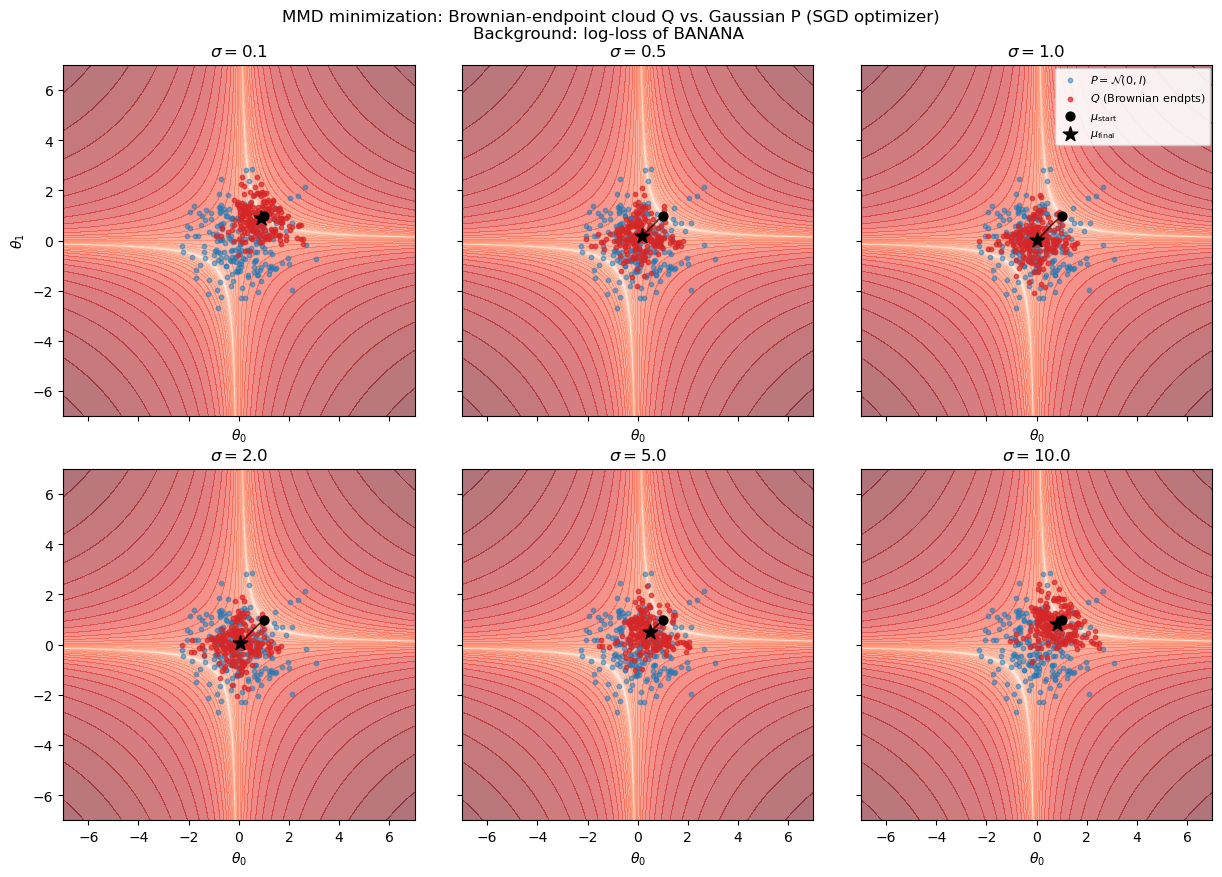

In [6]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(12.6, 8.8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()   # flatten 3x2 array -> iterable list

for ax, res in zip(axes, results):
    ax.contourf(GX, GY, LOG_LOSS, levels=25, cmap="Reds", alpha=0.55)
    xs = np.linspace(-7.0, 7.0, 400)
    xs_nz = xs[np.abs(xs) > 0.3]
    #ax.plot(xs_nz, 1.0 / xs_nz, color="orange", lw=1.0, ls="--",
            #label=r"$\theta_0\theta_1=1$")

    Xp = res["X_p_final"]
    Xq = res["X_q_final"]
    ax.scatter(Xp[:, 0], Xp[:, 1], s=10, alpha=0.5, color="tab:blue",
               label=r"$P=\mathcal{N}(0,I)$")
    ax.scatter(Xq[:, 0], Xq[:, 1], s=10, alpha=0.7, color="tab:red",
               label=r"$Q$ (Brownian endpts)")

    mu_path = res["mu_hist"]
    ax.plot(mu_path[:, 0], mu_path[:, 1], color="black", lw=1.2, alpha=0.7)
    ax.scatter([mu_path[0, 0]], [mu_path[0, 1]], color="black", marker="o",
               s=40, label=r"$\mu_{\mathrm{start}}$")
    ax.scatter([mu_path[-1, 0]], [mu_path[-1, 1]], color="black", marker="*",
               s=120, label=r"$\mu_{\mathrm{final}}$")

    ax.set_xlim(-7.0, 7.0)
    ax.set_ylim(-7.0, 7.0)
    ax.set_aspect("equal")
    ax.set_title(rf"$\sigma = {res['sigma']}$")
    ax.set_xlabel(r"$\theta_0$")

axes[0].set_ylabel(r"$\theta_1$")
#axes[-1].legend(loc="upper right", fontsize=7, framealpha=0.9)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.92),
    fontsize=8,
    framealpha=0.9
)

fig.suptitle(
    "MMD minimization: Brownian-endpoint cloud Q vs. Gaussian P (SGD optimizer)\n"
    "Background: log-loss of BANANA ",
    fontsize=12,
)
fig.tight_layout()
fig.subplots_adjust(hspace=0.15)
plt.show()

## Plot 2 — MMD$^2$ during optimization

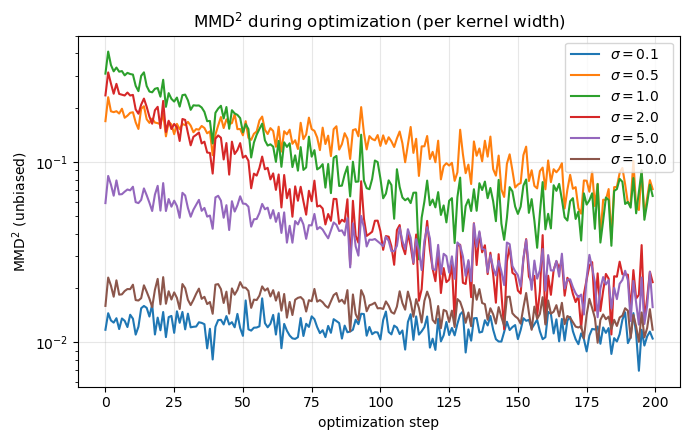

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for res in results:
    ax.plot(res["mmd_hist"], label=rf"$\sigma={res['sigma']}$")
ax.set_xlabel("optimization step")
ax.set_ylabel(r"MMD$^2$ (unbiased)")
ax.set_yscale("log")
ax.set_title("MMD$^2$ during optimization (per kernel width)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 3 — $\mu$ trajectories on the loss landscape

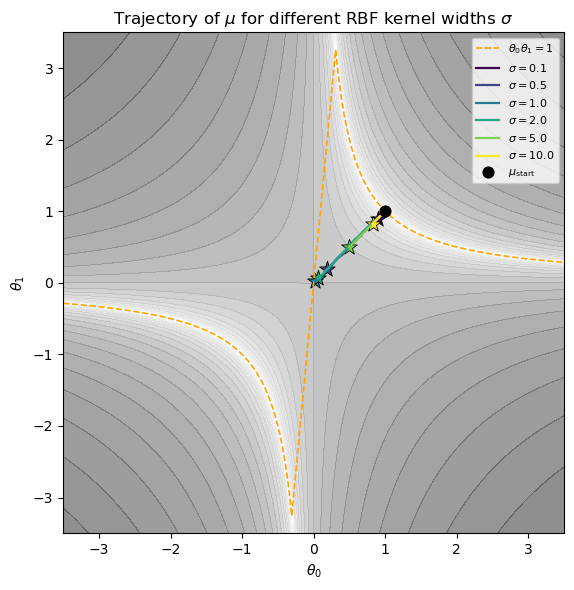

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(GX, GY, LOG_LOSS, levels=25, cmap="Greys", alpha=0.6)
xs = np.linspace(-3.5, 3.5, 400)
xs_nz = xs[np.abs(xs) > 0.3]
ax.plot(xs_nz, 1.0 / xs_nz, color="orange", lw=1.2, ls="--",
        label=r"$\theta_0\theta_1=1$")

cmap = plt.get_cmap("viridis")
for i, res in enumerate(results):
    color = cmap(i / max(1, len(results) - 1))
    mp = res["mu_hist"]
    ax.plot(mp[:, 0], mp[:, 1], color=color, lw=1.6,
            label=rf"$\sigma={res['sigma']}$")
    ax.scatter([mp[-1, 0]], [mp[-1, 1]], color=color, marker="*", s=140,
               edgecolor="black", linewidth=0.6)

ax.scatter([MU_START[0].item()], [MU_START[1].item()],
           color="black", s=60, marker="o", label=r"$\mu_{\mathrm{start}}$",
           zorder=5)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect("equal")
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_title(r"Trajectory of $\mu$ for different RBF kernel widths $\sigma$")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## Summary

In [9]:
print("=== Final mu per sigma ===")
for res in results:
    print(f"  sigma={res['sigma']:>4} -> mu_final={res['mu_final']}  "
          f"final MMD^2={res['mmd_hist'][-1]:.5f}")

=== Final mu per sigma ===
  sigma= 0.1 -> mu_final=[0.89931348 0.89597565]  final MMD^2=0.01050
  sigma= 0.5 -> mu_final=[0.18139759 0.1913993 ]  final MMD^2=0.07083
  sigma= 1.0 -> mu_final=[0.01619808 0.02322954]  final MMD^2=0.06485
  sigma= 2.0 -> mu_final=[0.05857814 0.06134207]  final MMD^2=0.02157
  sigma= 5.0 -> mu_final=[0.49404369 0.49465473]  final MMD^2=0.01569
  sigma=10.0 -> mu_final=[0.82255116 0.82280576]  final MMD^2=0.01177


In [10]:
SIGMA_SNAP = 10.0
MU_START_SNAP = torch.tensor([1.0, 1.0])
N_OPT_STEPS_SNAP = 200
SNAP_STEPS = [0, 10, 25, 50, 100, 200]   # iterations to save (0 = before any update)

torch.manual_seed(SEED)
np.random.seed(SEED)

sampler_snap = Brownian_sampler(
    metric=metric,
    walk_len=WALK_LEN,
    step_size=STEP_SIZE,
    n_samples=N_SAMPLES,
)

mu = torch.nn.Parameter(MU_START_SNAP.clone().to(dtype=torch.float64))
opt = torch.optim.SGD([mu], lr=LR)

snapshots = {}    # iter -> dict(mu, X_q, X_p, mmd2)
mu_hist_snap = [mu.detach().cpu().numpy().copy()]
mmd_hist_snap = []

def take_snapshot(it):
    with torch.no_grad():
        torch.manual_seed(SEED + 1000 + it)   # fixed RNG so snapshots are comparable
        Xq = sampler_snap.sample_q_endpoints(mu, detach_from_mu=True, drift=False)
        Xp = sampler_snap.sample_prior(mu.dtype, mu.device, DIM)
        m  = MMD_loss_unbiased(Xq, Xp, param=SIGMA_SNAP).item()
    snapshots[it] = {
        "mu": mu.detach().cpu().numpy().copy(),
        "X_q": Xq.cpu().numpy(),
        "X_p": Xp.cpu().numpy(),
        "mmd2": m,
    }

# snapshot at iter 0 (before any update)
take_snapshot(0)

for k in range(1, N_OPT_STEPS_SNAP + 1):
    X_q = sampler_snap.sample_q_endpoints(mu, detach_from_mu=False, drift=False)
    X_p = sampler_snap.sample_prior(mu.dtype, mu.device, DIM)
    mmd2 = MMD_loss_unbiased(X_q, X_p, param=SIGMA_SNAP)

    opt.zero_grad()
    mmd2.backward()
    opt.step()

    mu_hist_snap.append(mu.detach().cpu().numpy().copy())
    mmd_hist_snap.append(mmd2.item())

    if k in SNAP_STEPS:
        take_snapshot(k)

mu_hist_snap = np.array(mu_hist_snap)
print("snapshots taken at iters:", sorted(snapshots.keys()))

snapshots taken at iters: [0, 10, 25, 50, 100, 200]


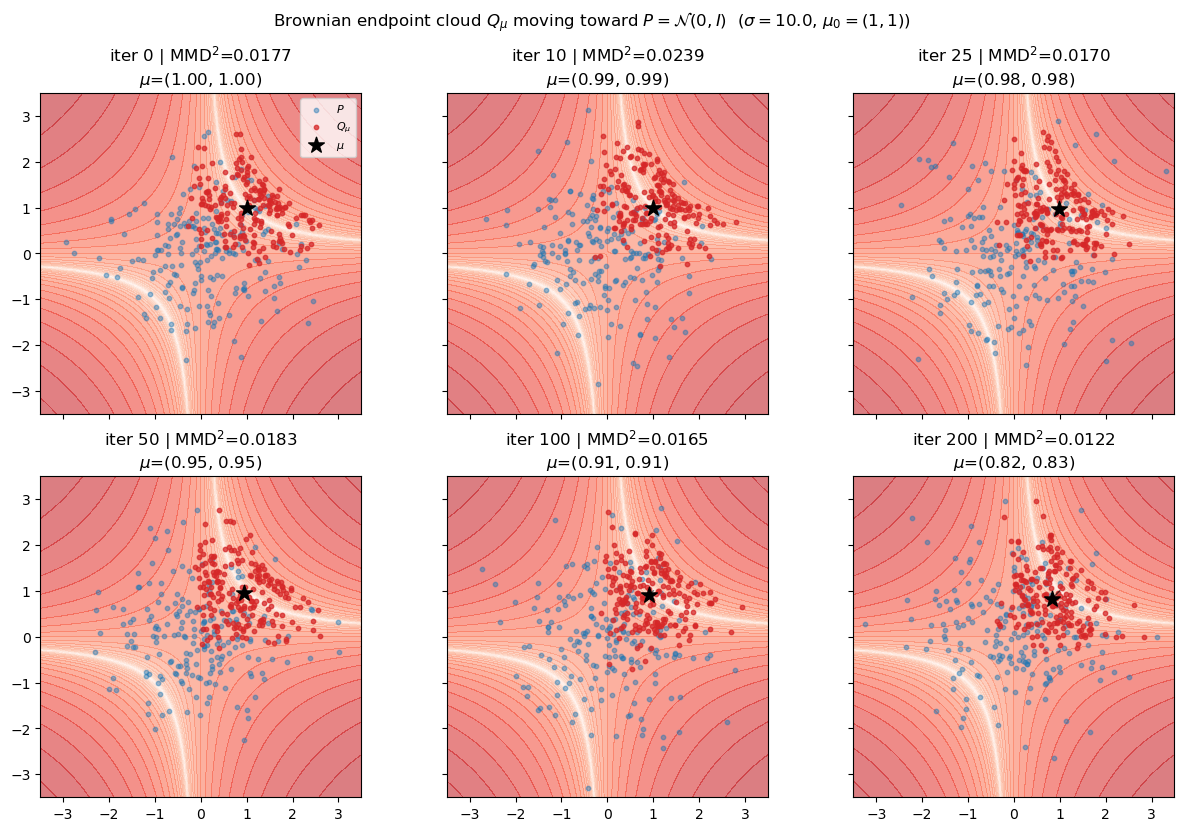

In [11]:
iters = sorted(snapshots.keys())
ncols = 3
nrows = int(np.ceil(len(iters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows),
                         sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

xs = np.linspace(-3.5, 3.5, 400)
xs_nz = xs[np.abs(xs) > 0.3]

for ax, it in zip(axes, iters):
    snap = snapshots[it]
    ax.contourf(GX, GY, LOG_LOSS, levels=25, cmap="Reds", alpha=0.55)
    #ax.plot(xs_nz, 1.0 / xs_nz, color="orange", lw=1.0, ls="--")

    ax.scatter(snap["X_p"][:, 0], snap["X_p"][:, 1], s=10, alpha=0.45,
               color="tab:blue", label=r"$P$")
    ax.scatter(snap["X_q"][:, 0], snap["X_q"][:, 1], s=10, alpha=0.75,
               color="tab:red", label=r"$Q_\mu$")

    mp = mu_hist_snap[: it + 1]
    ax.plot(mp[:, 0], mp[:, 1], color="black", lw=1.0, alpha=0.6)
    ax.scatter([snap["mu"][0]], [snap["mu"][1]], color="black", marker="*",
               s=140, zorder=5, label=r"$\mu$")

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect("equal")
    ax.set_title(rf"iter {it} | MMD$^2$={snap['mmd2']:.4f}"
                 f"\n$\\mu$=({snap['mu'][0]:.2f}, {snap['mu'][1]:.2f})")

for ax in axes[len(iters):]:
    ax.axis("off")

axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle(
    rf"Brownian endpoint cloud $Q_\mu$ moving toward $P=\mathcal{{N}}(0,I)$  "
    rf"($\sigma={SIGMA_SNAP}$, $\mu_0=(1,1)$)",
    fontsize=12,
)
fig.tight_layout()
plt.show()